## Detección Dengue con datos clínicos

### 1. Planteo Del Problema

#### Problema a resolver
El problema a resolver es la detección temprana de dengue a partir de resultados de análisis de sangre clínicos (hemograma completo), utilizando técnicas de machine learning para clasificar si un paciente presenta o no la enfermedad.

#### ¿Por qué es relevante?
El dengue es una enfermedad viral transmitida por el mosquito *Aedes aegypti* que representa uno de los mayores desafíos de salud pública en América Latina y en Argentina en particular.

**Contexto regional:** En 2024, el continente americano enfrentó la epidemia de dengue más grande desde que comenzaron los registros en 1980, con más de 12,6 millones de casos documentados, incluyendo más de 21.000 casos graves y más de 7.700 muertes.  Argentina, Brasil, Colombia y México concentraron el 90% de los casos registrados en la región. 

**Contexto nacional:** En Argentina, durante 2024 se registraron 548.862 casos, con una tasa acumulada de 1.203 casos por cada 100.000 habitantes y 415 muertes en 18 jurisdicciones.  Los años 2023 y 2024 representaron dos epidemias de magnitud sin precedentes, concentrando el 83% del total de casos históricos registrados.  En la temporada 2024-2025 se observó una recuperación significativa: se registraron 17.964 casos confirmados, una reducción drástica frente al año anterior.  Sin embargo, la enfermedad mantiene carácter endémico en zonas del norte del país y especialistas advierten que puede reaparecer de forma irregular y extenderse a nuevas regiones. 

**Relevancia del diagnóstico temprano:** El diagnóstico clínico del dengue sin laboratorio presenta limitaciones importantes, ya que sus síntomas iniciales son comunes a otras enfermedades. La detección automática a partir de parámetros de hemograma —como el recuento de plaquetas y glóbulos blancos, que se alteran característicamente en el dengue— puede ser una herramienta de apoyo valiosa para el personal de salud, especialmente en contextos de alta demanda asistencial durante picos epidémicos.

**Vacunación:** La ANMAT aprobó en 2023 la vacuna tetravalente Qdenga (Takeda), aunque la estrategia adoptada es focalizada y no universal, ya que no impide la infección en el 100% de los casos.  Por ello, el diagnóstico temprano por hemograma sigue siendo una herramienta clave e independiente de la cobertura vacunal.

Fuentes: [OPS - Dengue por país](https://www.paho.org/es/arbo-portal/dengue-datos-analisis/dengue-analisis-por-pais) | [Ministerio de Salud - Cierre de temporada 2024-2025](https://www.argentina.gob.ar/noticias/cierre-de-temporada-de-dengue-mediante-una-estrategia-innovadora-se-fortalecio-la) | [Estrategia Nacional de Vacunación](https://www.argentina.gob.ar/estrategia-nacional-de-vacunacion-focalizada)

### 2. Datos

#### Dataset utilizado
El dataset utilizado es el **Dengue Detection Dataset (Clinical Data)**, disponible públicamente en Kaggle. <br>
Fue creado con fines académicos y de investigación, y sus datos son de naturaleza sintética. <br>
Por lo que los mismos reflejan las distribuciones estadísticas y patrones clínicos típicos del dengue, pero no corresponden a pacientes reales.

Fuente: [Dengue Detection Dataset – Kaggle](https://www.kaggle.com/datasets/aravind3505/dengue-detection-dataset-clinical-data)

#### Descripción del contenido
El dataset contiene resultados de análisis de sangre clínicos (hemograma completo) junto con una etiqueta de diagnóstico. Cada registro representa un paciente con las siguientes variables:

| Variable | Descripción |
|---|---|
| `age` | Edad del paciente |
| `gender` | Sexo del paciente |
| `hemoglobin_g_dl` | Hemoglobina (g/dL) |
| `wbc_count` | Recuento de glóbulos blancos |
| `differential_count` | Conteo diferencial de leucocitos |
| `rbc_count` | Recuento de glóbulos rojos |
| `platelet_count` | Recuento de plaquetas |
| `platelet_distribution_width` | Amplitud de distribución plaquetaria (PDW) |
| `dengue_label` | Variable objetivo: 1 = dengue, 0 = no dengue |

In [21]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "Dengue_diseases_dataset_modified (1).csv"

df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "aravind3505/dengue-detection-dataset-clinical-data",
  file_path,
)

df.head()

,age,gender,hemoglobin_g_dl,wbc_count,differential_count,rbc_count,platelet_count,platelet_distribution_width,dengue_label
0,43,Male,12.6,2200.0,1,1,62000.0,11.0,1
1,45,Male,13.2,3000.0,0,1,17000.0,17.0,1
2,50,Female,11.0,3300.0,1,1,19000.0,16.3,1
3,57,Female,11.9,3500.0,1,0,29000.0,14.0,1
4,51,Female,13.0,3100.0,0,1,30000.0,14.5,1


### 3. Preparación De Datos

#### Limpieza de datos
**Valores nulos**:
Para entrenar el modelo, nos interesa saber cuantos valores nulos existen.<br>
Para analizar que tan importante son esas variables en el dengue, primero tenemos que tratar esos valores nulos para hacer la matriz de correlación y analizar su relación con "dengue_label".<br>

**Tipos de datos**:
También es importante notar que de df.info() obtenemos los tipos de datos.<br>
De ahí observamos que gender es un object por lo que tenemos que convertirlo con la técnica one-hot encoding a un boolean o entero con 1 y 0.

##### One-hot encoding:
Vemos que gender es "Male" o "Female".<br>
Para analizar si el genero del paciente influye en si tiene dengue o no, primero debemos convertir esa variable en algo medible, en un numero.<br>
Para eso utilizamos la técnica One-hot encoding

In [22]:
from matplotlib import axes
import pandas as pd

df = pd.get_dummies(df, columns=['gender'], prefix='gender', dtype=int).drop(columns=['gender_Child', 'gender_Female'])

df.head()

,age,hemoglobin_g_dl,wbc_count,differential_count,rbc_count,platelet_count,platelet_distribution_width,dengue_label,gender_Male
0,43,12.6,2200.0,1,1,62000.0,11.0,1,1
1,45,13.2,3000.0,0,1,17000.0,17.0,1,1
2,50,11.0,3300.0,1,1,19000.0,16.3,1,0
3,57,11.9,3500.0,1,0,29000.0,14.0,1,0
4,51,13.0,3100.0,0,1,30000.0,14.5,1,0


##### Análisis de valores nulos:
Para poder entrenar el dataset debemos tratar los valores nulos.<br>
Para eso primero vemos las columnas que tienen valores nulos y si es viable eliminar las filas que contengan valores nulos o se debe recurrir a técnicas para llenar los mismos si los vamos a utilizar para el entrenamiento del modelo.

In [23]:
df.isnull().sum()

age                             0
hemoglobin_g_dl                 0
wbc_count                      24
differential_count              0
rbc_count                       0
platelet_count                 16
platelet_distribution_width    19
dengue_label                    0
gender_Male                     0
dtype: int64

Columnas con valores nulos:
- wbc_count
- platelet_count
- platelet_distribution_width

Vemos como resolverlo eliminando las filas con valores nulos o llenando los valores nulos por una media de la colunna o algún valor representativo.<br>

In [24]:
df_clean = df.dropna()

print(f"Filas originales: {len(df)}")
print(f"Filas después de dropna: {len(df_clean)}")
print(f"Filas eliminadas: {len(df) - len(df_clean)}")
print(f"Porcentaje de filas eliminadas: {(len(df) - len(df_clean)) / len(df) * 100:.2f}%")

Filas originales: 989
Filas después de dropna: 931
Filas eliminadas: 58
Porcentaje de filas eliminadas: 5.86%


Al momento de realizar pruebas entrenando el modelo, se observo una mejor precisión al eliminar las filas con valores nulos que utilizando la herramienta SimpleImputer para llenar los mismos.<br>

#### Selección de variables
Para ver que variables seleccionamos, tenemos que ver la correlación de las mismas con dengue_label, que es nuestra variable a predecir.<br>
También nos interesa ver si existen variables colineales que puedan afectar a la efectividad del modelo.

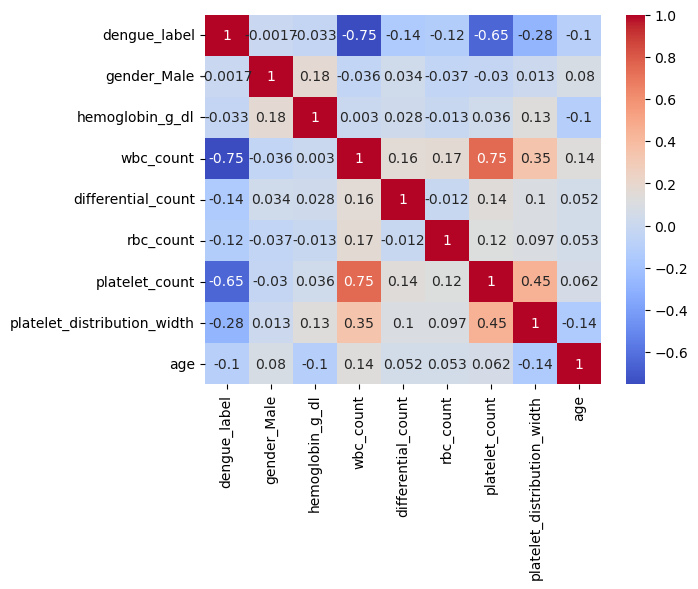

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df[['dengue_label',
                  'gender_Male',
                  'hemoglobin_g_dl',
                  'wbc_count',
                  'differential_count',
                  'rbc_count',
                  'platelet_count',
                  'platelet_distribution_width',
                  'age'
                  ]].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

Lo que más nos interesa de la matríz es "dengue_label".<br>
Donde podemos observar que las variables con mayor correlación son las siguientes:
- wbc_count
- platelet_count
- platelet_distribution_width
- differential_count
- rbc_count
- age

Si bien las variables wbc_count y platelet_count, al utilizar el modelo RandomForest, este no se debería ver afectado ante la colinealidad.<br>

Para entrenar el modelo se seleccionan estas variables, descartando age, gender_Male y hemoglobin_g_dl por su baja correlación con dengue_label.<br>

Para entrenar el modelo no seleccionamos solo las variables con más correlación wbc_count y  platelet_count porque como se puede ver existen casos donde no se agrupan de forma uniforme con solo estas variables.<br>
Por este motivo se probaron con distintas combinaciones y terminamos agregando más variables para entrenar el modelo con correlación más baja.

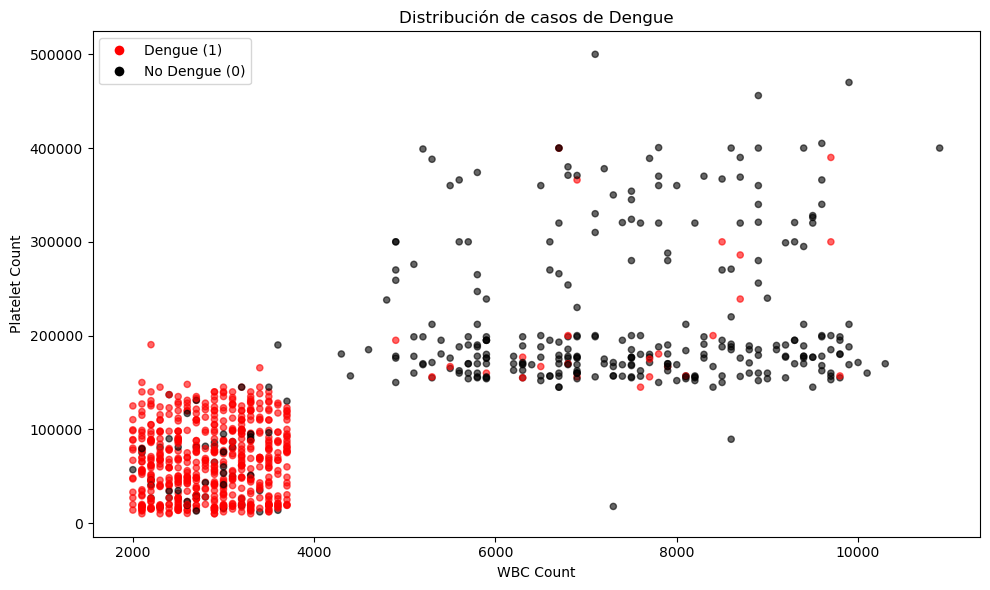

In [26]:
import matplotlib.pyplot as plt

colors = df['dengue_label'].map({1: 'red', 0: 'black'})

plt.figure(figsize=(10, 6))
plt.scatter(
    df['wbc_count'], df['platelet_count'],
    c=colors, alpha=0.6, s=20
)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Dengue (1)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='black', markersize=8, label='No Dengue (0)')
]
plt.legend(handles=legend_elements)

plt.xlabel('WBC Count')
plt.ylabel('Platelet Count')
plt.title('Distribución de casos de Dengue')
plt.tight_layout()
plt.show()

### 4. Modelo De Machine Learning

Para este proyecto utilizamos el algoritmo **Random Forest**, implementado a través de la librería `scikit-learn` [1].

Random Forest es un algoritmo de aprendizaje supervisado basado en el concepto de **ensamble**: en lugar de entrenar un único modelo, construye múltiples árboles de decisión de forma simultánea, cada uno entrenado sobre una submuestra aleatoria del dataset y utilizando un subconjunto aleatorio de features en cada split. Para clasificar un nuevo caso, cada árbol emite un voto y el modelo devuelve la clase con mayor cantidad de votos. Esta combinación de árboles diversos reduce la varianza del modelo y lo hace significativamente más robusto al overfitting que un árbol de decisión individual.

Elegimos Random Forest por las siguientes razones:

- **Robustez ante overfitting**: crítica en problemas de salud donde una mala generalización puede tener consecuencias clínicas directas.
- **No requiere escala de variables**: a diferencia de KNN, Random Forest no se ve afectado por diferencias de escala entre features como `wbc_count` y `platelet_distribution_width`.
- **Feature importance**: el algoritmo provee una métrica de importancia de variables, permitiendo identificar qué valores hematológicos tienen mayor poder predictivo para el diagnóstico de dengue.   

---
[1] Scikit-learn: Machine Learning in Python. Pedregosa et al., JMLR 12, pp. 2825-2830, 2011. https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

### 5. Entrenamiento y Prueba

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

#features = ['wbc_count', 'platelet_count', 'platelet_distribution_width', 'differential_count', 'rbc_count']
# luego de muchas iteracioens elegimos estas variables porque fueron las que mostraron mayor correlacion con la variable objetivo y mejor desempeño en el modelo
features = ['wbc_count', 'platelet_count', 'platelet_distribution_width', 'age']

df_features = df[features + ['dengue_label']]
df_clean_na = df_features.dropna()

X = df_clean_na[features]
y = df_clean_na['dengue_label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print(classification_report(y_test, model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.98      0.84      0.91        64
           1       0.92      0.99      0.96       123

    accuracy                           0.94       187
   macro avg       0.95      0.92      0.93       187
weighted avg       0.94      0.94      0.94       187



In [40]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')
print(f"F1 por fold: {scores.round(3)}")
print(f"F1 promedio: {scores.mean():.3f} ± {scores.std():.3f}")

F1 por fold: [0.925 0.92  0.963 0.949 0.897]
F1 promedio: 0.931 ± 0.023


In [41]:
# Prueba con pacientes de ejemplo
nuevos_pacientes = pd.DataFrame([
    {'wbc_count': 3000, 'platelet_count': 90000, 'platelet_distribution_width': 15.2, 'age': 25},
    {'wbc_count': 7000, 'platelet_count': 250000, 'platelet_distribution_width': 12.1, 'age': 40},
])

predicciones = model.predict(nuevos_pacientes)
probabilidades = model.predict_proba(nuevos_pacientes)

for i, (pred, prob) in enumerate(zip(predicciones, probabilidades)):
    print(f"Paciente {i+1}: {'Dengue' if pred == 1 else 'No Dengue'} "
          f"(probabilidad: {prob[pred]:.2%})")

Paciente 1: Dengue (probabilidad: 84.00%)
Paciente 2: No Dengue (probabilidad: 96.00%)


### 6. Interpretación De Resultados

Para evaluar el modelo utilizamos una parte del dataset obtenida de forma aleatoria (20%) para evaluar la precisión del modelo general.<br>
Además, utilizamos la técnica de cross validation para evaluar el comportamiento del modelo en datos para los que no fue entrenado y estimar su perfomance sin sesgos.<br>
Para poder visualizar su performance en falsos positivos y falsos negativos, utilizamos la matriz de confusión.

#### Cross Validation

Para la validación cruzada, analizamos la métrica **F1-Score**.  
Esta métrica va de 0 a 1, siendo 1 el modelo más preciso, y se calcula como la media armónica entre dos métricas:

- **Precisión:** de todas las predicciones positivas hechas, cuántas fueron correctas. Mide la calidad de las predicciones positivas.
- **Recall (Sensibilidad):** de todos los casos positivos reales, cuántos encontró el modelo. Mide la cobertura del modelo.

Elegimos F1-Score por sobre accuracy porque en un problema médico como el diagnóstico de dengue, tanto los falsos positivos como los falsos negativos tienen consecuencias clínicas relevantes.

La validación cruzada nos permite obtener estas métricas como si las estuviéramos calculando sobre datos que el modelo no vio durante el entrenamiento, reduciendo el sesgo que podría introducir un único split de test.

In [43]:
from sklearn.model_selection import cross_val_score

# Cross validation sobre el train
scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')

print(f"F1 por fold: {scores}")
print(f"F1 promedio: {scores.mean():.3f} +- {scores.std():.3f}")

# Evaluación final en test
print(classification_report(y_test, model.predict(X_test)))

F1 por fold: [0.92462312 0.92       0.96296296 0.94897959 0.89690722]
F1 promedio: 0.931 +- 0.023
              precision    recall  f1-score   support

           0       0.98      0.84      0.91        64
           1       0.92      0.99      0.96       123

    accuracy                           0.94       187
   macro avg       0.95      0.92      0.93       187
weighted avg       0.94      0.94      0.94       187



#### Feature Importance

El algoritmo Random Forest permite analizar qué variables tuvieron mayor influencia en las predicciones del modelo a través de la métrica de **importancia de features**.  
Esta métrica va de 0 a 1, indicando qué proporción del poder predictivo del modelo aporta cada variable. Valores cercanos a 1 indican que esa variable fue determinante para clasificar correctamente los casos.<br>
Como pudimos ver en la matriz de correlación las variables más importantes fueron:
- wbc_count
- platelet_count

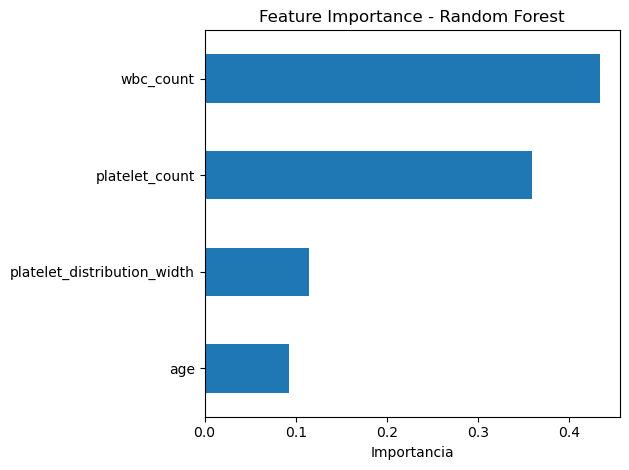

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(model.feature_importances_, index=features)
importances = importances.sort_values(ascending=True)

importances.plot(kind='barh')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

#### Matriz de Confusión

La matriz de confusión nos permite visualizar el desempeño del modelo comparando las predicciones contra los valores reales. Se compone de cuatro cuadrantes:

- **Verdaderos Positivos (VP):** casos de dengue que el modelo predijo correctamente como dengue.
- **Verdaderos Negativos (VN):** casos sin dengue que el modelo predijo correctamente como no dengue.
- **Falsos Positivos (FP):** casos sin dengue que el modelo predijo incorrectamente como dengue.
- **Falsos Negativos (FN):** casos con dengue que el modelo predijo incorrectamente como no dengue.

En un contexto clínico, los **Falsos Negativos** son los errores más críticos, ya que implican que un paciente con dengue no recibe atención a tiempo.<br>

En la matriz podemos observar que los FN es el error más bajo que presenta, lo que cumple nuestro objetivo de reducir el FP por su gravedad.

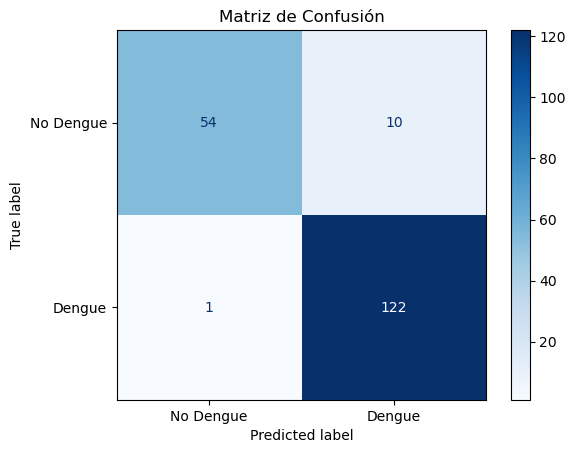

In [45]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test, model.predict(X_test),
    display_labels=['No Dengue', 'Dengue'],
    cmap='Blues'
)
plt.title('Matriz de Confusión')
plt.show()

#### Conclusión

Si bien obtuvimos resultados favorables, considerando el F1-Score de 0.95 y la alta precisión para hallar casos positivos (recall de 0.99 para dengue_label=1), nos encontramos con limitaciones por lo limitado del dataset (menos de 1000 entradas) y porque tuvimos que eliminar un ~5% del dataset porque contenia valores nulos.<br>

### 7. Aplicación Profesional

Si el notebook se replicará para un dataset con datos de pacientes reales, ajustando las respectivas variables de ser necesario, y se obtendrían resultados similares podría ser una aplicación util para un entorno clínico, sobre todo en epocas y regiones con epidemías de dengue, donde el personal médico se encuentra al borde su capacidad y el personal capacitado puede ser limitado en el area para interpretar los resultados.<br>

Para aplicar este modelo sería ideal integrarlo en un software médico donde pase automaticamente los análisis de laboratorio y se emitan alertas para los casos positivos, y donde el médico tenga la capacidad de consultar al modelo para verificar su diagnóstico.<br>
Además, podría ser útil para registrar automáticamente los casos diagnosticados, contribuyendo a la vigilancia epidemiológica de dengue en una región y reduciendo errores humanos como el olvido de cargar resultados o la omisión de estadísticas por parte del personal médico.

### 8. Herramientas de IA

Para el presente trabajo, utilizamos herramientas de IA para mejorar la redacción de las descripciones y puntos a realizar, para mejorar el estilo de los bloques de markdown, mejorar el estilo de código, entender el uso de las librerías y métricas para evaluar modelos, generar código boilerplate para diagrmas, gráficos, split de dataset, etc.<br>

Los aportes que realizamos fueron el analizar los datos del dataset, entender las variables que componían el mismo y elegir las mejores variables para entrenar el modelo, investigar en documentación y foros para seleccionar el modelo que más se adeque a las necesidades del problema, exponer como se puede entender las métricas que surgen de testaear a un modelo.

Herramientas de IA utilizadas: Claude, Gemini